# Classificacao de SPAMs em mensagens SMS com Naive Bayes

Aprenderemos um pouco de extracao de features textuais (Vetorizacao / Bag of Words).

Utilizaremos diferentes tipos de Classificadores Naive Bayes.

Analisaremos os resultados dos modelos criados utilizando Matriz de Confusao, Precision, Recall, F1, ROC Curve, ROC-AUC.

Dataset:

https://archive.ics.uci.edu/ml/datasets/SMS+Spam+Collection

#### Imports

In [1]:
import requests
from io import StringIO

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import RocCurveDisplay #
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import ConfusionMatrixDisplay

#### Carga do Dataset

In [2]:
orig_url='https://drive.google.com/file/d/19qYhN6D7h65WBUdNMUsboyJv5qlQeNbh/view?usp=sharing'
file_id = orig_url.split('/')[-2]
dwn_url='https://drive.google.com/uc?export=download&id=' + file_id
url = requests.get(dwn_url).text
csv_raw = StringIO(url)
df = pd.read_csv(csv_raw, encoding = "ISO-8859-1")
df.head()

,label,text,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## Pre-processamento

In [3]:
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)

In [4]:
df.shape

(5572, 2)

In [5]:
df.isnull().sum()

,0
label,0
text,0


In [6]:
df['label'].value_counts()

,count
label,
ham,4825
spam,747


In [7]:
df.describe()

,label,text
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [8]:
df['label'].unique()

array(['ham', 'spam'], dtype=object)

In [9]:
sdf = df.loc[(df.label == 'spam')]
sdf.describe()

,label,text
count,747,747
unique,1,653
top,spam,Please call our customer service representativ...
freq,747,4


In [10]:
hdf = df.loc[(df.label == 'ham')]
hdf.describe()

,label,text
count,4825,4825
unique,1,4516
top,ham,"Sorry, I'll call later"
freq,4825,30


In [11]:
enc = OrdinalEncoder(categories=[['ham', 'spam']], dtype=np.int8)
df['label'] = enc.fit_transform(df[['label']].values)

In [12]:
df.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## Datset Split

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X = df.drop(columns='label')
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,shuffle=True,random_state=0,stratify=y)

In [15]:
X_train.shape

(4457, 1)

In [16]:
X_test.shape

(1115, 1)

## Extracao de Features Textuais

### Definindo o Vetorizador de Termos

In [17]:
# instanciando o vetorizador
cvec = CountVectorizer(stop_words ='english')

# TODO 1 parametro
cvec.fit(df['text'])

CountVectorizer(stop_words='english')

In [18]:
cvec.vocabulary_

{'jurong': 4204,
 'point': 5721,
 'crazy': 2265,
 'available': 1272,
 'bugis': 1703,
 'great': 3523,
 'world': 8201,
 'la': 4329,
 'buffet': 1701,
 'cine': 1990,
 'got': 3483,
 'amore': 1052,
 'wat': 8001,
 'ok': 5323,
 'lar': 4365,
 'joking': 4172,
 'wif': 8108,
 'oni': 5349,
 'free': 3254,
 'entry': 2866,
 'wkly': 8159,
 'comp': 2106,
 'win': 8120,
 'fa': 2995,
 'cup': 2323,
 'final': 3111,
 'tkts': 7496,
 '21st': 411,
 '2005': 402,
 'text': 7367,
 '87121': 784,
 'receive': 6094,
 'question': 5989,
 'std': 7006,
 'txt': 7677,
 'rate': 6041,
 'apply': 1129,
 '08452810075over18': 77,
 'dun': 2729,
 'say': 6428,
 'early': 2748,
 'hor': 3802,
 'nah': 5074,
 'don': 2643,
 'think': 7420,
 'goes': 3447,
 'usf': 7813,
 'lives': 4516,
 'freemsg': 3261,
 'hey': 3720,
 'darling': 2380,
 'week': 8046,
 'word': 8192,
 'like': 4466,
 'fun': 3312,
 'tb': 7301,
 'xxx': 8266,
 'chgs': 1944,
 'send': 6515,
 '50': 607,
 'rcv': 6053,
 'brother': 1674,
 'speak': 6888,
 'treat': 7611,
 'aids': 986,
 'pate

In [19]:
cvec.get_feature_names_out()

array(['00', '000', '000pes', ..., 'zoom', 'zouk', 'zyada'], dtype=object)

## Transformando os Dados de Treino e Teste

In [21]:
X_train_transf = cvec.transform(X_train['text'])
X_test_transf = cvec.transform(X_test['text'])
#X_test_transf.toarray()

## Treinando e executando o modelo

In [27]:
# Define o estimador
est = MultinomialNB(alpha=1)
#est = BernoulliNB()

# Treina o modelo
est.fit(X_train_transf,y_train)

# Realiza as predicoes
y_pred = est.predict(X_test_transf)

# TODO 1 parametro
y_pred_prob = est.predict_proba(X_test_transf)

### Entendendo o conteudo das probabilidades

In [ ]:
#observando o conteudo de y_pred_prob
#y_pred_prob #exibe conteudo
#y_pred[0] # classificacao para o 1o exemplo
#y_pred_prob[0] #probabilidades para primeiro exemplo (para cada classe)
#y_pred_prob[0][0] + y_pred_prob[0][1]  # approx 1.0

In [28]:
y_pred_prob

array([[9.90513314e-01, 9.48668566e-03],
       [9.99988048e-01, 1.19522961e-05],
       [9.99949070e-01, 5.09303905e-05],
       ...,
       [1.00000000e+00, 1.73328908e-12],
       [9.99677021e-01, 3.22979454e-04],
       [9.21931126e-01, 7.80688741e-02]])

## Analise dos Resultados

### Observando a Matriz de Confusao

In [29]:
confusion_matrix(y_test,y_pred)

array([[948,  18],
       [ 12, 137]])

### Calculando as Metricas

In [30]:
print('Accuracy: ', accuracy_score(y_test,y_pred), '\n')
print('Precision: ', precision_score(y_test,y_pred), '\n')
print('Recall: ', recall_score(y_test,y_pred), '\n')
print('F1: ', f1_score(y_test,y_pred))

Accuracy:  0.9730941704035875 

Precision:  0.8838709677419355 

Recall:  0.9194630872483222 

F1:  0.9013157894736842


### Curva ROC (ROC-Curve)

#### Calculando os elementos da Curva ROC

In [31]:
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_pred_prob[:,1])

In [32]:
print('False Positive Rates:\n\n', false_positive_rate, '\n')
print('True Positive Rates:\n\n', true_positive_rate, '\n')
print('Thresholds:\n\n', thresholds)

False Positive Rates:

 [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.00414079 0.00414079 0.00517598
 0.00517598 0.00724638 0.00724638 0.01345756 0.01345756 0.01449275
 0.01449275 0.02380952 0.02380952 0.03312629 0.03312629 0.03519669
 0.03726708 0.04347826 0.04347826 0.04554865 0.04968944 0.05175983
 0.05175983 0.06004141 0.06625259 0.07039337 0.08281573 0.08488613
 0.11904762 0.12111801 0.14803313 0.15010352 0.16149068 0.16149068
 0.17494824 0.17701863 0.1884058  0.1884058  0.19565217 0.19565217
 0.19772257 0.19979296 0.22049689 0.22256729 0.23291925 0.23291925
 0.2484472  0.2505176  0.25465839 0.25983437 0.25983437 0.27846791
 0.2805383  0.28571429 0.28778468 0.34161491 0.3436853  0.38716356
 0.38923395 0.39648033 0.39855072 0.42443064 0.42650104 0.4989648
 0.5010352  0.53519669 0.53726708 0.54554865 0.54865424 0.6242236
 0.626294   0.66356108 0.66563147 0.69151139 0.69151139 

#### Plotando o grafico da Curva ROC

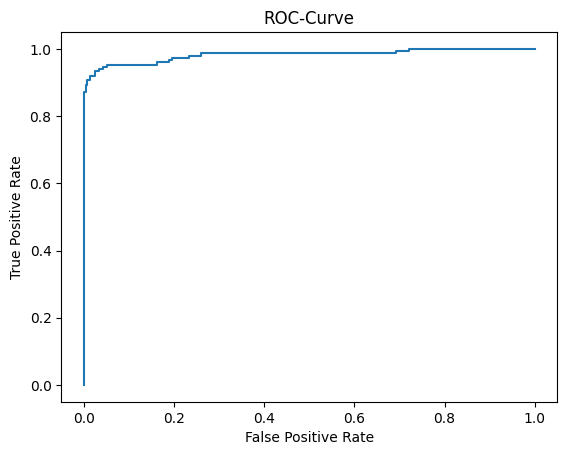

In [33]:
%matplotlib inline
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.title('ROC-Curve')
plt.plot(false_positive_rate, true_positive_rate)

#### Calculando a ROC-AUC

In [34]:
roc_auc = auc(false_positive_rate, true_positive_rate)
print('ROC-AUC: ', roc_auc)

ROC-AUC:  0.9819917462170161


### Curva-PR (PR-Curve)

#### Calculando os elementos da PR-Curve

In [36]:
#TODO 3 variaveis de retorno
#TODO 2 parametros
precision, recall, thresholds = precision_recall_curve(y_test,y_pred_prob[:,1])

#### Plotando o grafico da PR-Curve

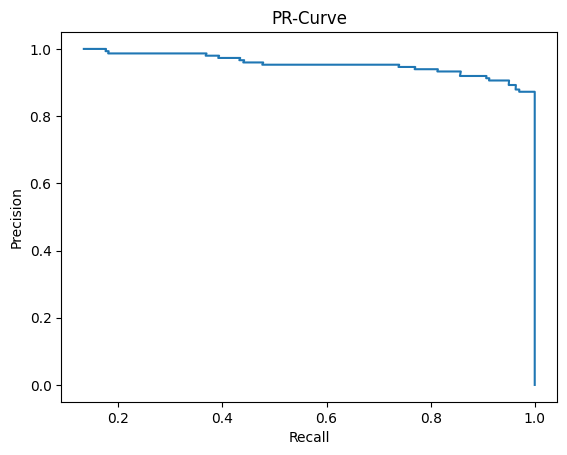

In [37]:
%matplotlib inline
plt.ylabel('Precision')
plt.xlabel('Recall')
plt.title('PR-Curve')
plt.plot(precision,recall) #2 TODO parametros

In [38]:
pr_auc = auc(false_positive_rate,true_positive_rate) #2 TODO parametros
print('PR-AUC: ', pr_auc)

PR-AUC:  0.9819917462170161


#### Calculando a PR-AUC

In [39]:
pr_auc = auc(recall, precision)
print('PR-AUC: ', pr_auc)

PR-AUC:  0.9605594581249074


### Fazendo plots mais facilmente

#### Curva-ROC (ROC-Curve)

Utilizando RocCurveDisplay.from_estimator(..) para plotar a curva ROC diretamente, sem calcular os elementos antes

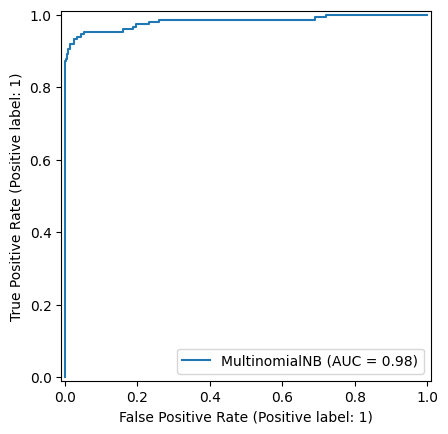

In [42]:
RocCurveDisplay.from_estimator(est,X_test_transf,y_test)
plt.show()

#### PR-Curve
Plotando a PR-Curve com PrecisionRecallDisplay.from_estimator(...)

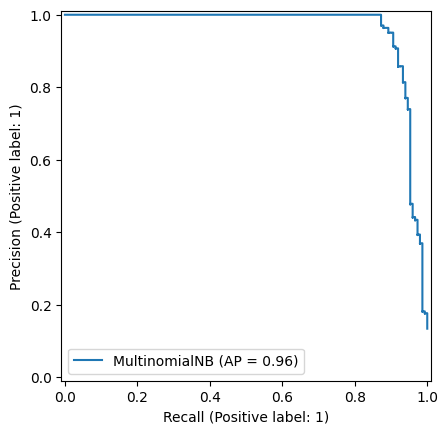

In [44]:
PrecisionRecallDisplay.from_estimator(est,X_test_transf,y_test)
plt.show()

#### Plotando a Matriz de Confusao



Sem Formatacao

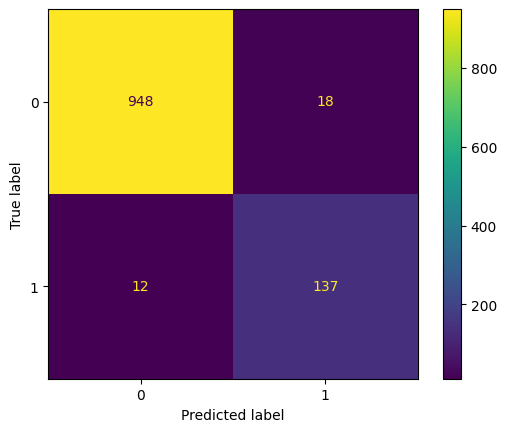

In [45]:
ConfusionMatrixDisplay.from_estimator(est,X_test_transf,y_test)
plt.show()

Plote a Matriz com uma Formatacao diferente (outras cores, por exemplo)

In [47]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [48]:
cm = confusion_matrix(y_test,y_pred, normalize='true')
class_names = ['Not-Spam (negative)', 'Spam (positive)']

Text(158.22222222222223, 0.5, 'Classe Real')

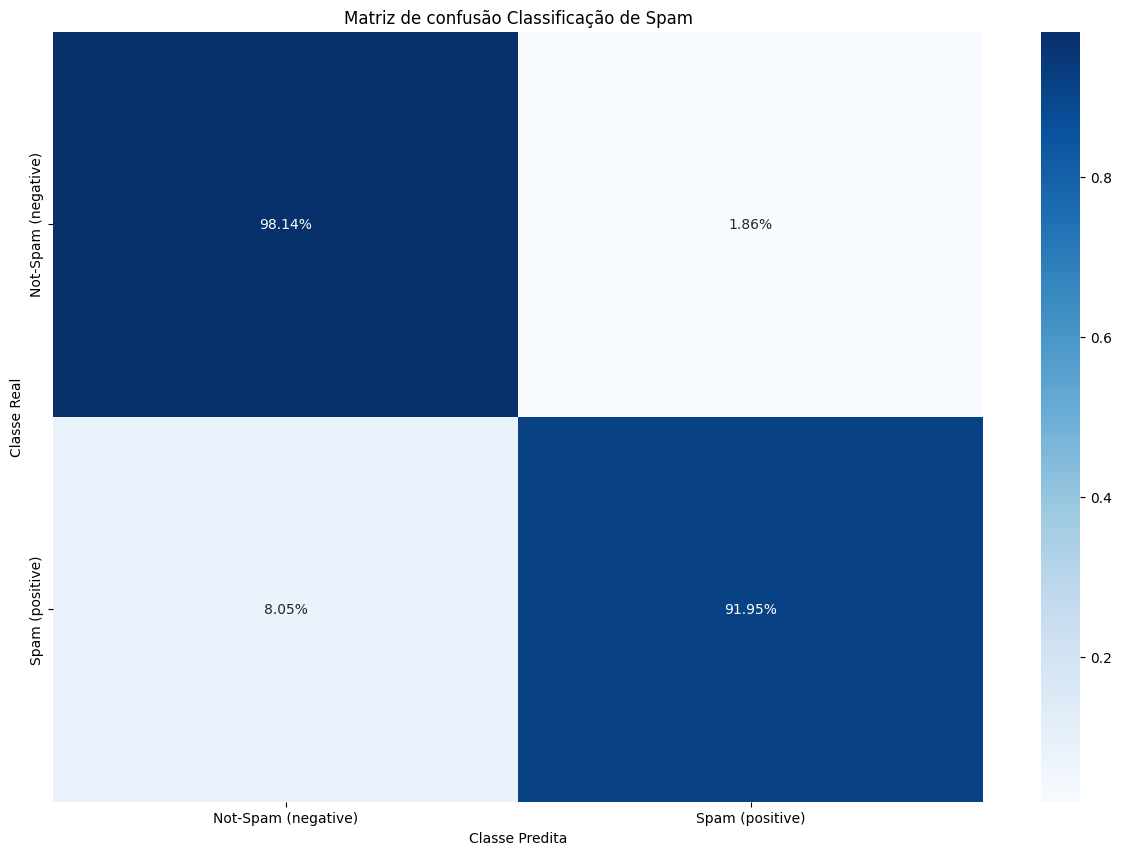

In [51]:
plt.figure(figsize=(15,10))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2%",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap='Blues'
)
plt.title("Matriz de confusão Classificação de Spam")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")